In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
print("\n--- Available Columns ---")
print(df.columns.tolist())


--- Available Columns ---
['index', 'stream', 'Zscore', 'district_rank', 'island_rank', 'al_year', 'sub1', 'sub1_r', 'sub2', 'sub2_r', 'sub3', 'sub3_r', 'cgt_r', 'ge_r', 'syllabus', 'birth_day', 'birth_month', 'birth_year', 'gender']



--- Average Zscore by Stream ---
                   stream    Zscore
0                       - -0.559565
1                    ARTS  0.471709
2      BIOLOGICAL SCIENCE  0.605670
3   BIOSYSTEMS TECHNOLOGY  0.487594
4                COMMERCE  0.496799
5  ENGINEERING TECHNOLOGY  0.463566
6                     NON  0.466774
7        PHYSICAL SCIENCE  0.638276


/tmp/ipykernel_2409/1248352246.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='stream', y='Zscore', data=stream_zscore_avg, palette='viridis')


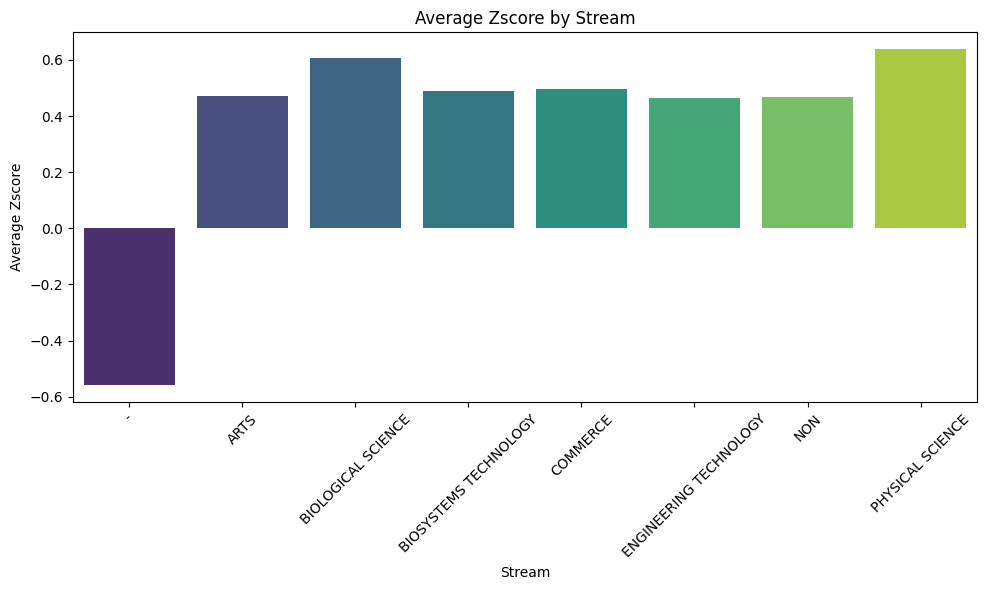

In [5]:
df['Zscore'] = pd.to_numeric(df['Zscore'], errors='coerce')
stream_zscore_avg = df.groupby('stream')['Zscore'].mean().reset_index()
print("\n--- Average Zscore by Stream ---")
print(stream_zscore_avg)

# Optional: Visualize the average Zscore by stream
plt.figure(figsize=(10, 6))
sns.barplot(x='stream', y='Zscore', data=stream_zscore_avg, palette='viridis')
plt.title('Average Zscore by Stream')
plt.xlabel('Stream')
plt.ylabel('Average Zscore')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
print("\n--- Summary Statistics for Zscore ---")
print(df['Zscore'].describe())


--- Summary Statistics for Zscore ---
count    231871.000000
mean          0.305907
std           0.763785
min          -1.938300
25%          -0.299700
50%           0.222300
75%           0.853300
max           3.558300
Name: Zscore, dtype: float64


## ETL: Extraction Step

This step involves loading the raw data from its source into a pandas DataFrame. In this case, we're reading the `2020_al_data_kaggle_upload_new_old_syllabi.csv` file.

In [7]:
# Read the uploaded CSV file into a pandas DataFrame
df_extracted = pd.read_csv('2020_al_data_kaggle_upload_new_old_syllabi.csv')

print("--- Data Extracted Successfully ---")
print(df_extracted.head()) # Display the first 5 rows of the extracted data

--- Data Extracted Successfully ---
   index    stream   Zscore district_rank  island_rank  al_year  \
0      0      ARTS   -0.355    4336 (NEW)  64994 (NEW)     2020   
1      1      ARTS  -0.2648    4154 (NEW)  62338 (NEW)     2020   
2      2  COMMERCE   -0.476    6910 (NEW)  37307 (NEW)     2020   
3      3  COMMERCE  -0.1012    5678 (NEW)  30449 (NEW)     2020   
4      4  COMMERCE   0.6014    3269 (NEW)  17010 (NEW)     2020   

                sub1 sub1_r               sub2 sub2_r        sub3 sub3_r  \
0  POLITICAL SCIENCE      S  DANCING(BHARATHA)      C       TAMIL      S   
1  POLITICAL SCIENCE      S     CARNATIC MUSIC      C       TAMIL      C   
2          ECONOMICS      S   BUSINESS STUDIES      S  ACCOUNTING      S   
3          ECONOMICS      C   BUSINESS STUDIES      C  ACCOUNTING      S   
4          ECONOMICS      C   BUSINESS STUDIES      C  ACCOUNTING      B   

  cgt_r ge_r syllabus birth_day birth_month birth_year  gender  
0    56    S      new        31        

## ETL: Transformation Step

This step involves cleaning and preparing the data for analysis. Here, we'll remove rows with null values in the 'Zscore' column, as requested, to ensure data quality for subsequent calculations.

In [8]:
# Remove rows with null values in the 'Zscore' column
initial_rows = df_extracted.shape[0]
df_extracted.dropna(subset=['Zscore'], inplace=True)
cleaned_rows = df_extracted.shape[0]

print(f"Removed {initial_rows - cleaned_rows} rows with null 'Zscore' values.")
print("DataFrame after cleaning 'Zscore' nulls:")
display(df_extracted.head())

Removed 3 rows with null 'Zscore' values.
DataFrame after cleaning 'Zscore' nulls:


,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-0.355,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,56,S,new,31,May,2001,female
1,1,ARTS,-0.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,32,C,new,13,January,2002,female
2,2,COMMERCE,-0.476,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,50,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,34,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,36,S,new,7,August,2000,female


In [9]:
# Convert 'Zscore' column to numeric type
df_extracted['Zscore'] = pd.to_numeric(df_extracted['Zscore'], errors='coerce')

print("Data type of 'Zscore' column after conversion:")
print(df_extracted['Zscore'].dtype)
print("First 5 rows of df_extracted with updated 'Zscore' type:")
display(df_extracted.head())

Data type of 'Zscore' column after conversion:
float64
First 5 rows of df_extracted with updated 'Zscore' type:


,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-0.3550,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,56,S,new,31,May,2001,female
1,1,ARTS,-0.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,32,C,new,13,January,2002,female
2,2,COMMERCE,-0.4760,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,50,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,34,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,36,S,new,7,August,2000,female
